In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
path = "/Users/macbookpro/Documents/Churn Data Analysis/Churn Data/Customer Churn.csv"

df = pd.read_csv(path)

df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


# Checking data details using info()

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Replacing null in (totalCharges) with 0 as tenure is 0 respectively 

In [4]:
df["TotalCharges"] = df["TotalCharges"].replace(" ", "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
# df.isnull().sum()


df.isnull().sum().sum()

0

In [15]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [7]:
#df.duplicated().sum()

df["customerID"].duplicated().sum()

0

# Converting 0 and 1 of (SeniorCitizen) to Yes/No to make it easy to understand

In [3]:
def conv(value):
    if value == 0:
       return "False"
    else:
       return "True"

df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)

In [22]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,False,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,False,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,False,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,False,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,False,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   str    
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

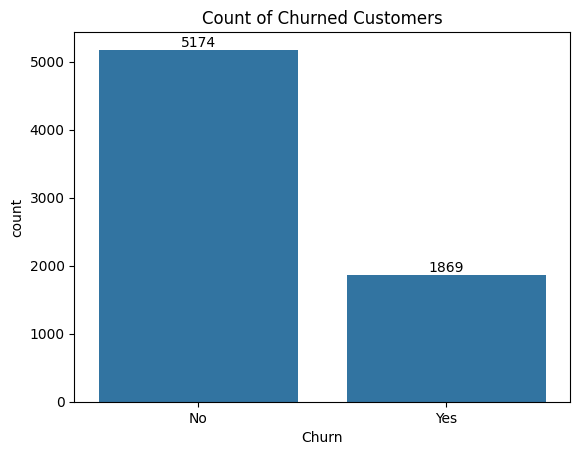

In [43]:
az= sns.countplot(x = "Churn", data = df)
az.bar_label(az.containers[0])
plt.title("Count of Churned Customers")
plt.show()

Text(0.5, 1.0, 'Percentage Of Churned Customers')

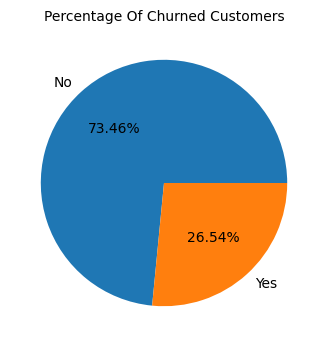

In [44]:
za = df.groupby("Churn").agg({"Churn":"count"})
za
plt.figure(figsize=(4,4))
plt.pie(za["Churn"], labels = za.index, autopct=("%1.2f%%"))
plt.title("Percentage Of Churned Customers", fontsize = 10)

# from the given chart we can conclude that 26.54% of customers have churned out

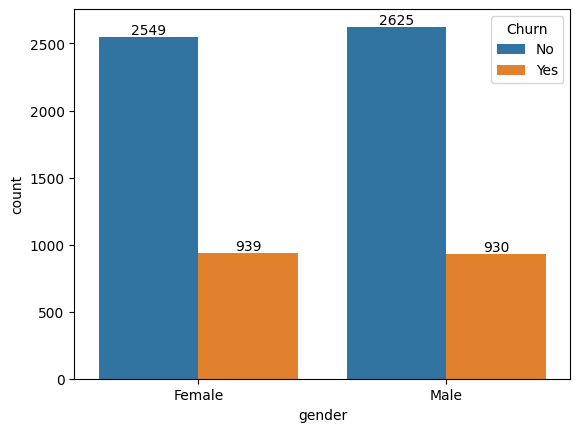

In [58]:
zz = sns.countplot(x = ("gender"), data = df, hue = ("Churn"))
zz.bar_label(zz.containers[0])
zz.bar_label(zz.containers[1])
plt.show()

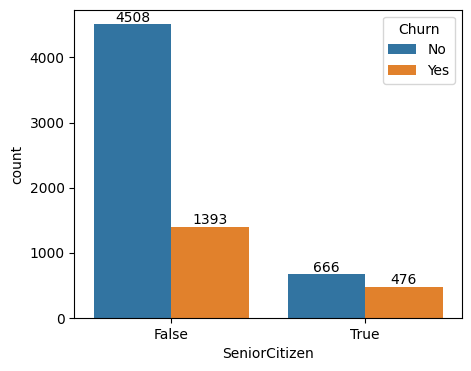

In [6]:
plt.figure(figsize = (5,4))
az = sns.countplot(x = ("SeniorCitizen"), data = df, hue = "Churn")
az.bar_label(az.containers[0])
az.bar_label(az.containers[1])
plt.show()

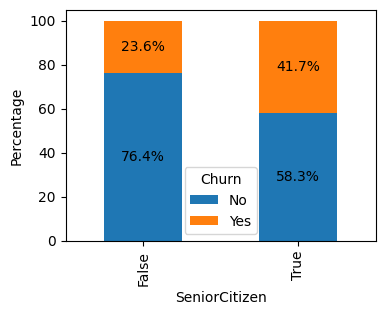

In [71]:
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

ax = ct.plot(kind='bar', stacked=True, figsize=(4,3))

for c in ax.containers:
    ax.bar_label(c, fmt='%.1f%%', label_type='center')

plt.ylabel('Percentage')
plt.show()

# comparetively greater percentage  of people in  Senior Citizen have churned

<function matplotlib.pyplot.show(close=None, block=None)>

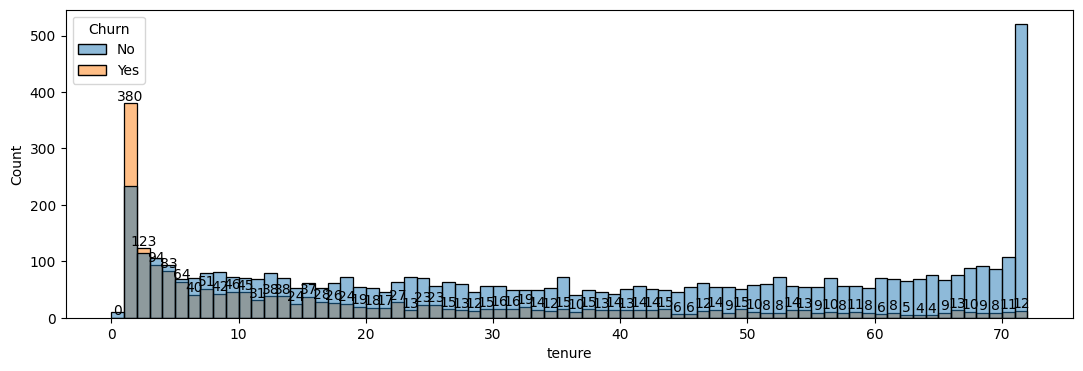

In [11]:
plt.figure(figsize = (13,4))
az = sns.histplot(x = "tenure", data = df, bins = 72, hue = "Churn")
az.bar_label(az.containers[0])
plt.show

In [13]:
df = df.groupby("Churn").agg({"Churn" : "count"})
df

,Churn
Churn,
No,5174
Yes,1869


# People who were in their 1st and second month of tenure have churned out the most

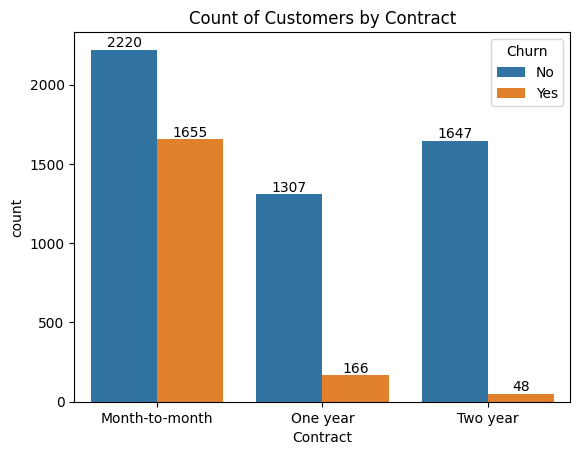

In [9]:
az =  sns.countplot(x = "Contract" , data = df, hue = "Churn")
az.bar_label(az.containers[0])
az.bar_label(az.containers[1])
plt.title("Count of Customers by Contract")
plt.show()

In [8]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

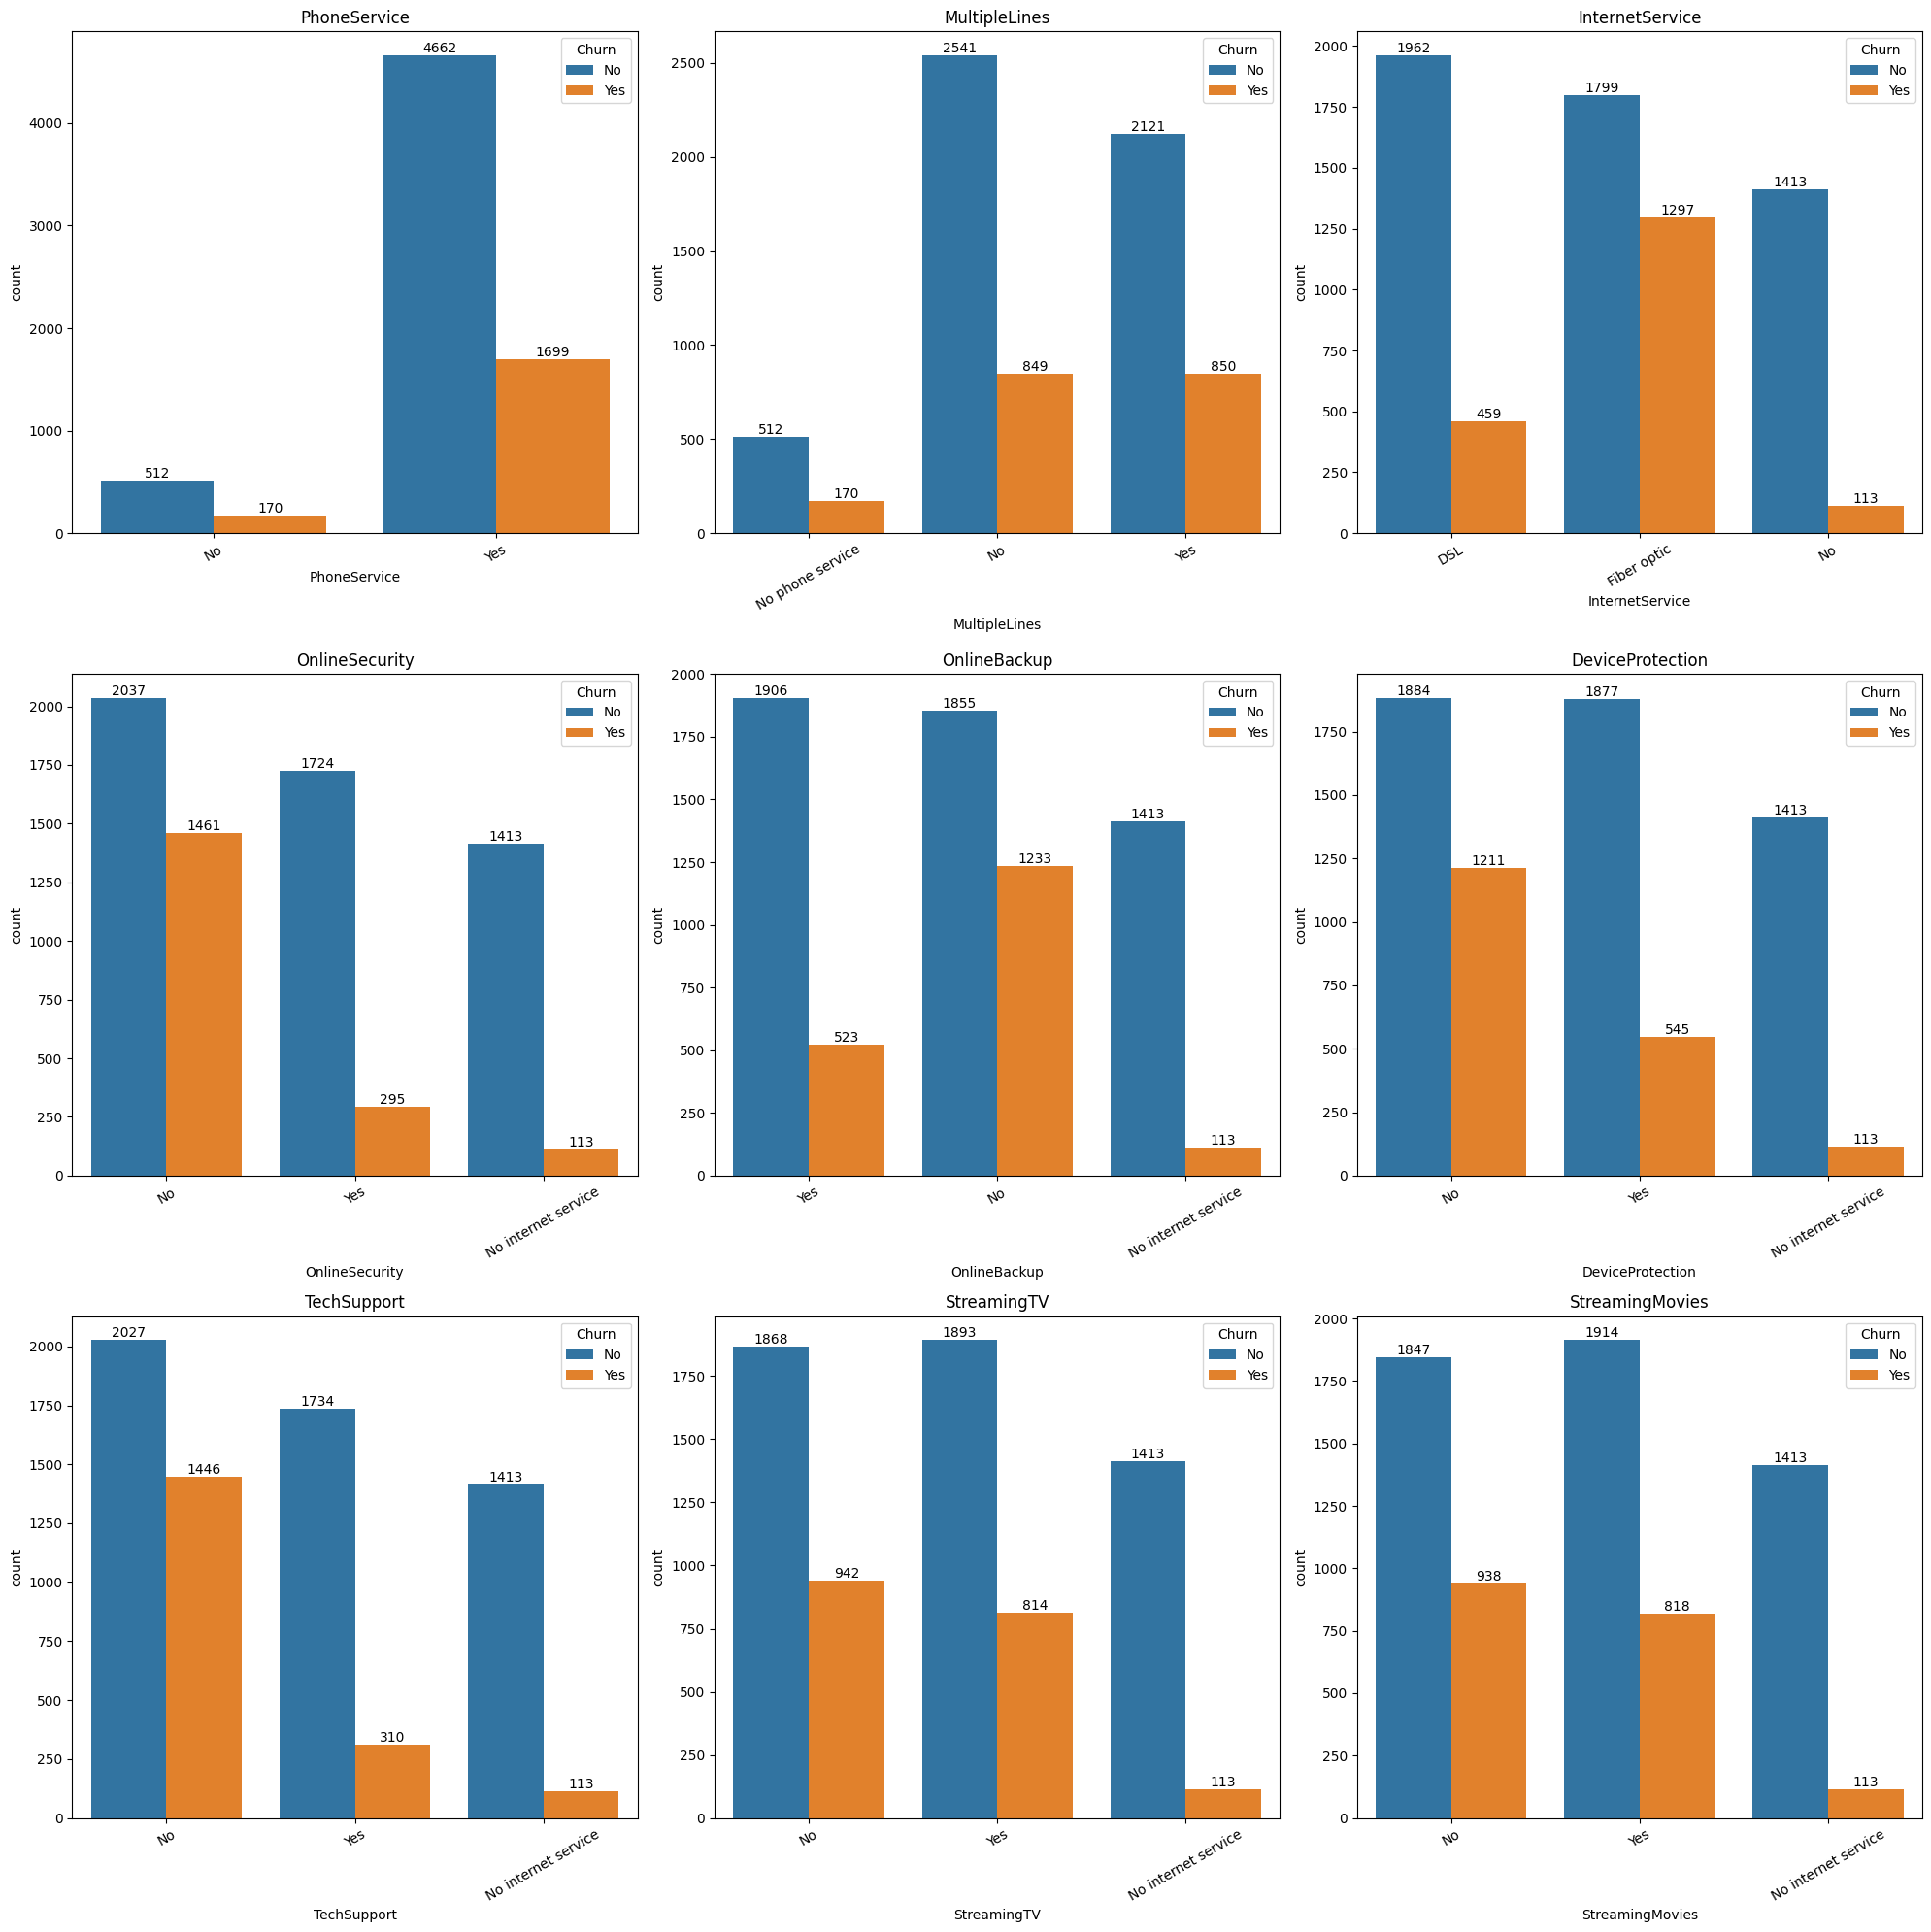

In [25]:

cols = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

fig, axes = plt.subplots(3, 3, figsize=(20, 20))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = sns.countplot(x=col, data=df, hue='Churn', ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=30)
    
    # labels for each hue bar
    for container in ax.containers:
        ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

# Churn is consistently much higher among users lacking services like OnlineSecurity, TechSupport, and OnlineBackup—these look like strong retention drivers.
# Customers with Fiber optic internet show noticeably higher churn compared to DSL or no internet, hinting at pricing or service quality issues.
# Having multiple lines or phone service doesn’t strongly reduce churn, so these features alone aren’t sticky enough.
# Overall, value-added services (security, support, backup) are the clearest differentiators between retained and churned customers.

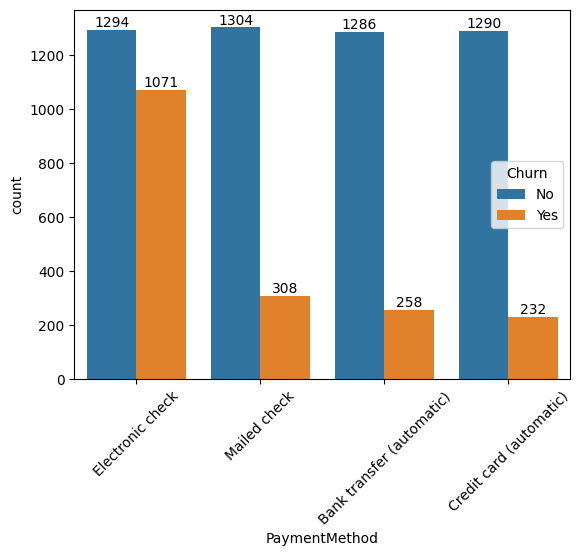

In [28]:
az = sns.countplot(x = "PaymentMethod", data = df, hue = "Churn")
az.bar_label(az.containers[0])
az.bar_label(az.containers[1])
plt.xticks(rotation = 45)
plt.show()

In [ ]:
¡